# Pips & librerias

In [7]:
! pip install PyMySQL
! pip install cryptography
! pip install mysql-connector-python

In [1]:
import pymysql
import sys
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Conexión con MySQL

In [2]:
# Conexión
connection = pymysql.connect(
    host="212.227.90.6",
    user="Equipo27",
    password="E1q2u3i4p5o27",
    database="Equip_27",
    port=3306
)

# Tablas
tablas = pd.read_sql("SHOW TABLES", connection).iloc[:, 0].tolist()

dfs = {}

for tabla in tablas:
    dfs[tabla] = pd.read_sql(f"SELECT * FROM {tabla}", connection)

print(dfs.keys())

# Selección principal
df = dfs['BANK_marketing']

# Cerrar conexión 
connection.close()


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_13016\3888609987.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  tablas = pd.read_sql("SHOW TABLES", connection).iloc[:, 0].tolist()
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_13016\3888609987.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  dfs[tabla] = pd.read_sql(f"SELECT * FROM {tabla}", connection)


dict_keys(['BANK_marketing'])


# Análisis exploratorio de datos (EDA)

## Exploración general:

In [9]:
df
#numero de filas check coincide con la exploracion de mysql

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,1,59.0,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,2,56.0,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,3,41.0,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,4,55.0,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,5,54.0,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10982,10983,40.0,management,married,secondary,no,8486,no,no,unknown,6,may,260,3,-1,0,unknown,no
10983,10984,53.0,management,married,tertiary,no,20772,no,no,cellular,4,feb,715,1,-1,0,unknown,no
10984,10985,55.0,blue-collar,married,primary,no,3297,yes,yes,telephone,30,apr,96,1,-1,0,unknown,no
10985,10986,41.0,management,married,tertiary,no,9,yes,no,cellular,22,jul,82,3,-1,0,unknown,no


In [ ]:
df.info()
#Ninguna columna tiene datos faltantes--> ventaja frente al cleaning
#Muchas columnas con tipo de variable en "object"-->hay que transformarlas de cara al cleaning

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10987 entries, 0 to 10986
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         10987 non-null  int64  
 1   age        10977 non-null  float64
 2   job        10987 non-null  object 
 3   marital    10982 non-null  object 
 4   education  10980 non-null  object 
 5   default    10987 non-null  object 
 6   balance    10987 non-null  int64  
 7   housing    10987 non-null  object 
 8   loan       10987 non-null  object 
 9   contact    10987 non-null  object 
 10  day        10987 non-null  int64  
 11  month      10987 non-null  object 
 12  duration   10987 non-null  int64  
 13  campaign   10987 non-null  int64  
 14  pdays      10987 non-null  int64  
 15  previous   10987 non-null  int64  
 16  poutcome   10987 non-null  object 
 17  deposit    10987 non-null  object 
dtypes: float64(1), int64(7), object(10)
memory usage: 1.5+ MB


## Resúmen estadístico:

In [12]:
#Resúmen de variables númericas:
df.describe()


,id,age,balance,day,duration,campaign,pdays,previous
count,10987.000000,10977.000000,10987.000000,10987.000000,10987.000000,10987.000000,10987.000000,10987.000000
mean,5494.000000,41.263004,1538.162738,15.651952,374.183763,2.505233,51.659052,0.838810
std,3171.818038,11.952308,3240.007771,8.424481,348.493183,2.725176,109.033750,2.302484
min,1.000000,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,2747.500000,32.000000,125.000000,8.000000,139.000000,1.000000,-1.000000,0.000000
50%,5494.000000,39.000000,556.000000,15.000000,256.000000,2.000000,-1.000000,0.000000
75%,8240.500000,49.000000,1723.000000,22.000000,501.000000,3.000000,40.000000,1.000000
max,10987.000000,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [13]:
#Resúmen de variables categóricas:
df.describe(include=['object'])

,job,marital,education,default,housing,loan,contact,month,poutcome,deposit
count,10987,10982,10980,10987,10987,10987,10987,10987,10987,10987
unique,12,3,4,2,2,2,3,12,4,2
top,management,married,secondary,no,no,no,cellular,may,unknown,no
freq,2535,6237,5387,10826,5804,9556,7928,2765,8176,5698


In [14]:
df.isnull().sum()

id            0
age          10
job           0
marital       5
education     7
default       0
balance       0
housing       0
loan          0
contact       0
day           0
month         0
duration      0
campaign      0
pdays         0
previous      0
poutcome      0
deposit       0
dtype: int64

In [15]:
# Proporción de clientes que aceptan la campaña
df['deposit'].value_counts()

deposit
no     5698
yes    5289
Name: count, dtype: int64

In [16]:
# Proporción de clientes que aceptan la campaña
df['deposit'].value_counts(normalize=True)

deposit
no     0.518613
yes    0.481387
Name: proportion, dtype: float64

In [39]:
# Distribución y posibles valores extremos
df['age'].describe()

count    10977.000000
mean        41.263004
std         11.952308
min         18.000000
25%         32.000000
50%         39.000000
75%         49.000000
max         95.000000
Name: age, dtype: float64

## Visualizaciones iniciales

Para identificarr tendencias y/o anomalías

### Edad

<Axes: >

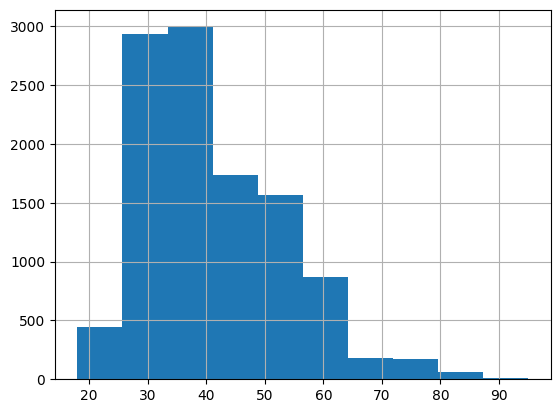

In [18]:
# Visualización de la distribución de la edad
df['age'].hist()

<Axes: >

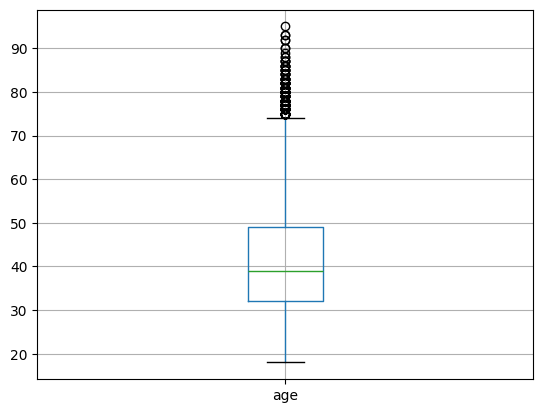

In [19]:
# Boxplot de la edad para visualizar la distribución y detectar posibles valores extremos
df.boxplot(column='age')

- La edad se concentra principalmente entre los 25 y 65 años
- Presenta una mayor densidad entre 25 y 40 años
- En edades más elevadas se presenta menor densidad notoriamente.

### Trabajo, estado civil y  nivel educativo

In [40]:
# Frecuencia de tipos de trabajo
df['job'].value_counts()

job
management       2535
blue-collar      1905
technician       1793
admin.           1318
services          906
retired           770
self-employed     398
student           359
unemployed        346
entrepreneur      320
housemaid         267
unknown            70
Name: count, dtype: int64

In [41]:
# Frecuencia de estado civil
df['marital'].value_counts()

marital
married     6237
single      3472
divorced    1273
Name: count, dtype: int64

In [42]:
# Frecuencia del nivel educativo
df['education'].value_counts()

education
secondary    5387
tertiary     3638
primary      1468
unknown       487
Name: count, dtype: int64

El perfil del cliente está dominado por:
- personas casadas
- nivel educativo principalmente secundario o superior
- Con ocupaciones en sectores como management, técnico y blue-collar.

### préstamos e hipotecas

In [50]:
# Presencia de préstamos personales
df['loan'].value_counts()

loan
no     9556
yes    1431
Name: count, dtype: int64

In [51]:
# Presencia de hipotecas
df['housing'].value_counts()

housing
no     5804
yes    5183
Name: count, dtype: int64

- La mayoría de los clientes no dispone de préstamos personales
- existe relativamente una cantidad cercana de clientes con y son hipotecas


### Campaign

In [44]:
# Estadísticas del número de contactos para analizar dispersión y posibles outliers
df['campaign'].describe()

count    10987.000000
mean         2.505233
std          2.725176
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         63.000000
Name: campaign, dtype: float64

<Axes: >

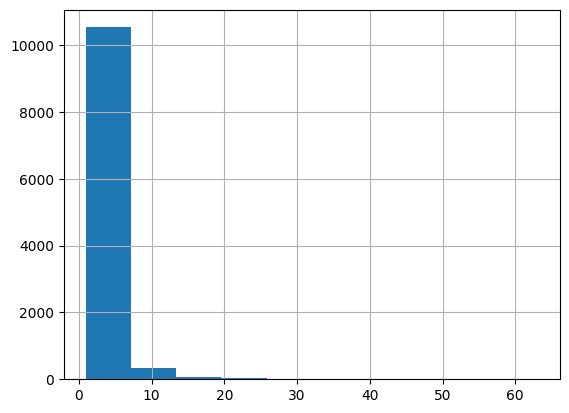

In [45]:
# Distribución del número de contactos
df['campaign'].hist()

<Axes: >

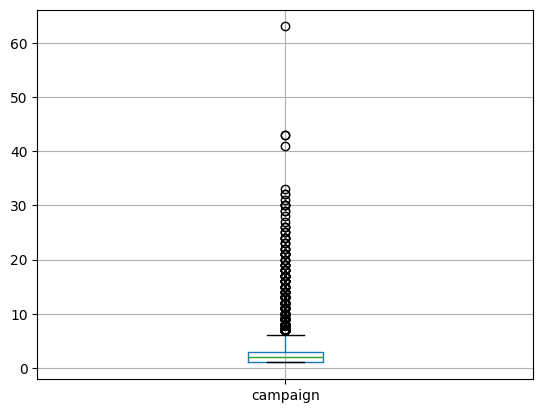

In [46]:
# Boxplot del número de contactos para analizar la dispersión y detectar posibles valores atípicos (outliers)
df.boxplot(column='campaign')

El número de contactos por cliente es generalmente bajo, concentrándose en menos de 3 intentos, aunque existen casos con valores significativamente más elevados.

### Tipo de contacto (contact)

In [26]:
# Frecuencia de los canales de contacto presentes en el dataset
df['contact'].value_counts()

contact
cellular     7928
unknown      2295
telephone     764
Name: count, dtype: int64

In [27]:
# Frecuencia por mes
df['month'].value_counts()

month
may    2765
aug    1495
jul    1487
jun    1209
nov     926
apr     912
feb     764
oct     390
jan     338
sep     316
mar     275
dec     110
Name: count, dtype: int64

- El canal más utilizado es el contacto celular
- mayor concentración de campañas en determinados meses, como mayo, agosto y julio.

### Balance

In [47]:
# Distribución de los saldos de los clientes
df['balance'].describe()

count    10987.000000
mean      1538.162738
std       3240.007771
min      -6847.000000
25%        125.000000
50%        556.000000
75%       1723.000000
max      81204.000000
Name: balance, dtype: float64

<Axes: >

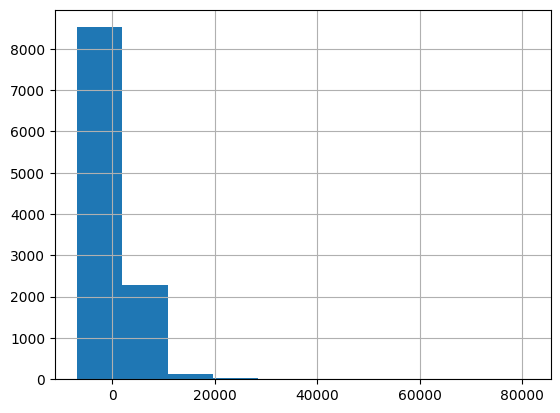

In [48]:
# Distribución del balance
df['balance'].hist()

<Axes: >

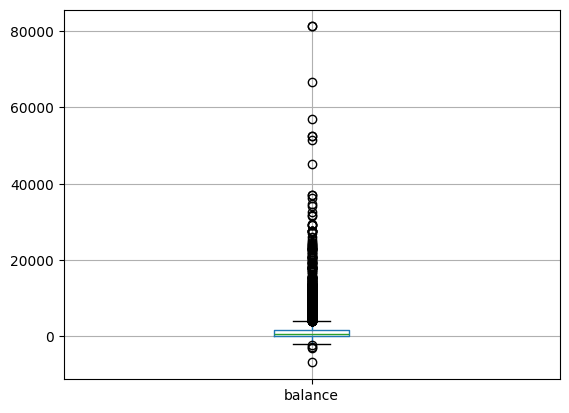

In [49]:
# # Boxplot del balance para identificar la dispersión y posibles valores atípicos (outliers)
df.boxplot(column='balance')

El balance presenta una distribución concentrada en valores bajos, con una alta dispersión y una notable presencia de valores atípicos, especialmente en la parte superior, lo que genera una distribución asimétrica.

### default

In [33]:
# Proporción de clientes en riesgo
df['default'].value_counts()

default
no     10826
yes      161
Name: count, dtype: int64

In [34]:
# Cómo se distribuye el balance en cada grupo
df.groupby('default')['balance'].describe()

,count,mean,std,min,25%,50%,75%,max
default,,,,,,,,
no,10826.0,1562.100129,3256.421009,-3058.0,134.0,568.0,1749.25,81204.0
yes,161.0,-71.440994,838.725781,-6847.0,-353.0,0.0,65.00,5249.0


La proporción de clientes en situación de impago es muy reducida. Además, se observan diferencias en la distribución del balance entre clientes con y sin default.

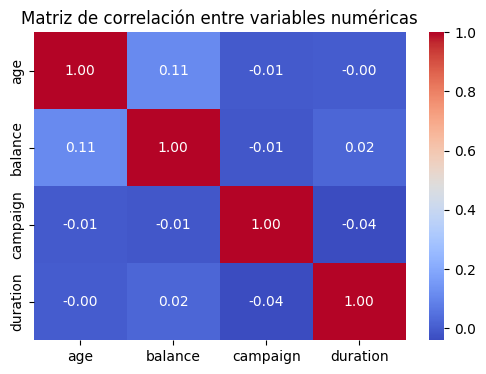

In [35]:
corr = df[['age','balance','campaign','duration']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de correlación entre variables numéricas")
plt.show()

Se analizan las relaciones entre variables numéricas, observándose que no existen correlaciones lineales fuertes entre ellas.

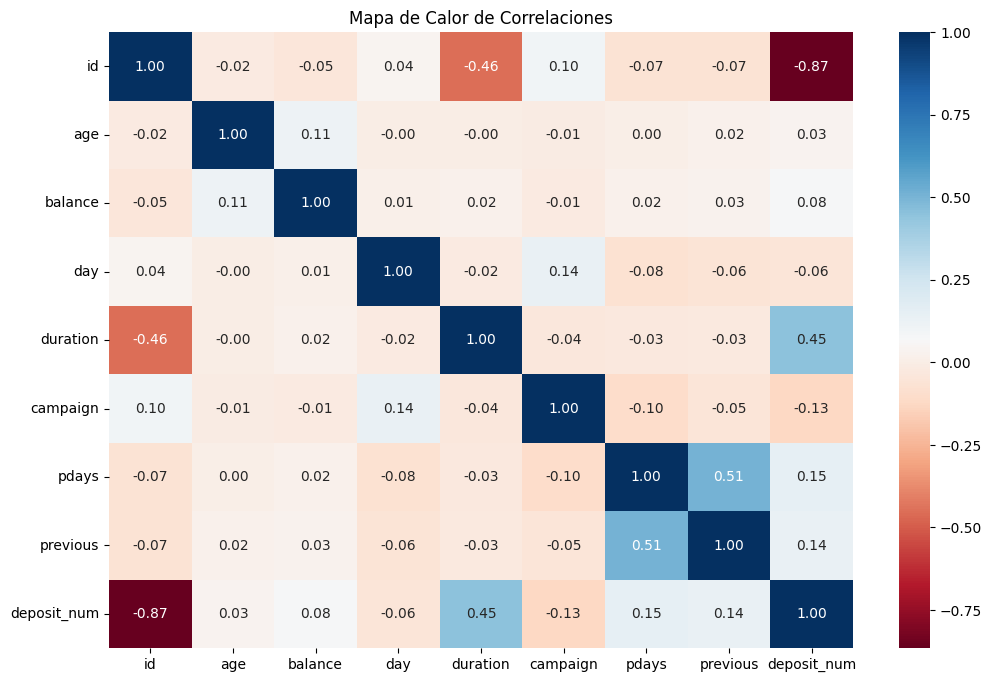

In [ ]:
df['deposit_num'] = df['deposit'].map({'yes': 1, 'no': 0})

plt.figure(figsize=(12,8))
corr_matrix = df.select_dtypes(include=['int64', 'float64']).corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', fmt=".2f")
plt.title('Mapa de Calor de Correlaciones')
plt.show()

- duration 0.45 --> El factor más influyente. Las llamadas largas cierran ventas.
- Pdays/Previous 0.15 --> El contacto previo ayuda, pero no es determinante por sí solo.
- edad/balance 0.03/0.08 -->Sorprendentemente baja. El dinero que tienen en la cuenta o su edad no garantizan que quieran un depósito a plazo.
- Campaign -0.13 --> inversamente proporcionla: Correlación negativa. Entre más veces llames al cliente en esta misma campaña, menos probable es que acepte

# Conclusión

- El dataset presenta una estructura completa y buena calidad de datos, con escasos valores nulos. La variable objetivo está equilibrada, lo que facilita el análisis posterior.

- El perfil de cliente se concentra principalmente en personas casadas, con educación secundaria y ocupaciones en sectores como management, técnico y blue-collar.

- El número de contactos suele ser bajo, aunque existen valores extremos, y el canal más utilizado es el contacto celular, con mayor actividad en ciertos meses.

- El balance muestra una alta dispersión, incluyendo valores extremos, mientras que las situaciones de impago son poco frecuentes.



En conjunto, los datos permiten abordar análisis posteriores desde distintas perspectivas de negocio.
